# Tier 0 version 2: the alpha sweep of Kumar et al. (2024), and the confound the movement statistic hides

**What this notebook adds to version 1.** Sections 1 to 4 are the Tier 0 reproduction and are unchanged.
Sections 5 to 8 are new. They are the H0 material of the report, the demonstration that the usual
kernel-movement statistic does not identify the mechanism, moved here from the Tier 1 notebook and
rebuilt.

**Why it was rebuilt.** The Tier 1 notebook made the H0 point by comparing the baseline cell against a
cell at weight decay 0.001. That comparison has three faults. The decay cell never memorises, so it is
open to the reply that it is a broken run rather than a confounded measurement. Its alignment is flat
only at the step chosen for the figure, and by the right-hand edge of the same panel it has risen above
the baseline cell. Its rotation term at that step is larger than the baseline cell's, not smaller. The
sections below make the same point with runs that all train and all grok, and keep the decay cell only
as a separate and clearly labelled case.

**The identity.** With the scale term S_t = log(||K_t|| / ||K_0||) and the shape term
R_t = 1 - <K_t / ||K_t||, K_0 / ||K_0||>, the squared relative movement is

    D^2 = ||K_t - K_0||^2 / ||K_0||^2 = exp(2 S_t) + 1 - 2 exp(S_t) (1 - R_t).

This is Equation 1 of the proposal and it is the group's own algebra. The centred alignment A_t is a
third quantity and does not appear in the identity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ntk_lib as L  # training loop, crossings, kernel terms and plot helpers shared by the tier notebooks

L.set_plot_style()

ALPHAS = [0.5, 1.0, 1.5, 2.0]
SEEDS = [0, 1, 2, 3, 4]
STEPS = 100000
TAU = 1e-2  # loss threshold for the pre-registered definition, applied to both losses

# Test accuracy at which the generalisation event is declared; the memorisation event is always train accuracy 1.
TEST_ACC_LEVEL = 1.0

# The decay levels of the Tier 1 grid, used by the H0 sections below.
DECAYS = [0.0, 1e-5, 3e-5, 1e-4, 3e-4]
GRID_ALPHAS = [0.5, 1.0, 2.0]

def saved(alpha, seed, ek=0.0):
    """True if this seed of the cell is already trained and saved under results/."""
    return (L.RESULTS / (L.cell_name(100, alpha, ek, seed) + ".json")).exists()

# Seed 0 of each alpha is always loaded, and trained first if missing; further seeds are used where saved.
runs = {(a, s): L.load_cell(100, a, 0.0, s, STEPS, eval_interval=500)
        for a in ALPHAS for s in SEEDS if s == 0 or saved(a, s)}

## How to read the tables and figures

**Grokking time** is the number of steps between two events: memorisation, when the network gets the training set right, and generalisation, when it gets the held-out test pairs right. Two definitions detect the events differently.

- **Accuracy definition (primary).** Memorisation is the first step at train accuracy 1. Generalisation is the first step at which test accuracy reaches `TEST_ACC_LEVEL`, set in the first code cell.
- **Loss definition.** Both events are the first step at which the loss falls below 0.01. The test loss settles between 0.01 and 0.03 long after accuracy is perfect, so this definition rarely records generalisation within a run.

**Censoring.** If generalisation has not happened when the run ends, the grokking time is known only to exceed the run length minus the memorisation step. Tables write such a bound with a plus sign; figures draw it as a triangle, with the true value above the marker, and a circle for a measured time.

**Dots on curves.** A hollow dot is the memorisation event and a filled dot the generalisation event of that run.


## 1. The two definitions on one run

Alpha 1, seed 0. Left: the two losses with the threshold as a dash-dot line. Right: the two accuracies with the levels 1 and `TEST_ACC_LEVEL`. The shaded band is the grokking time under each definition; an open-ended band means the test event never happened in the run.


Loss definition: memorisation step 7500, generalisation never within the run, grokking time >92500 steps.
Accuracy definition: memorisation step 4500, generalisation step 17000, grokking time 12500 steps.


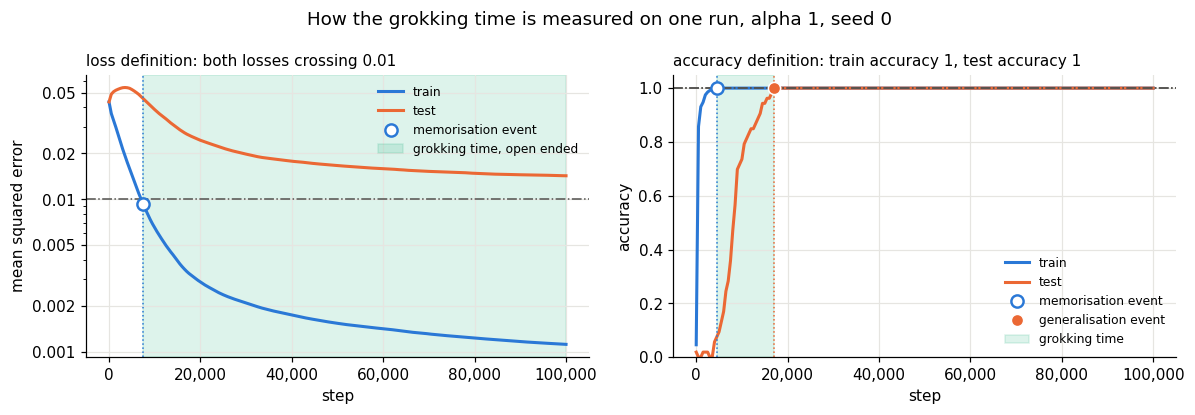

In [2]:
# One run, both definitions side by side, with the two events and the gap between them marked.
fig = L.plot_definitions(runs[(1.0, 0)], tau=TAU, test_level=TEST_ACC_LEVEL,
                         title="How the grokking time is measured on one run, alpha 1, seed 0")


## 2. Grokking time across alpha

One row per alpha: the mean over seeds with the standard deviation in brackets, and the number of censored seeds. A censored seed contributes its lower bound, so a row with censored seeds is itself a lower bound.


In [3]:
def summarise_alpha(definition):
    """Print, for each alpha, the mean and spread over seeds of the two crossings and the grokking time."""
    print(f"{'alpha':>6} {'seeds':>5} {'train crossing':>18} {'test crossing':>18} {'grokking time':>18} {'censored':>9}")
    for a in ALPHAS:
        # One summary per seed; summarise_cell returns the crossings under the chosen definition.
        rows = [L.summarise_cell(runs[(a, s)], definition, TAU, test_level=TEST_ACC_LEVEL) for s in SEEDS if (a, s) in runs]
        cols = []
        for key in ("t_train", "t_test", "t_grok"):
            vals = np.array([r[key] for r in rows if r[key] is not None], float)
            cols.append(f"{vals.mean():>8.0f} ({vals.std(ddof=1):>6.0f})" if len(vals) > 1 else f"{'-':>18}")
        print(f"{a:>6g} {len(rows):>5} {cols[0]:>18} {cols[1]:>18} {cols[2]:>18} {sum(r['censored'] for r in rows):>9}")

print(f"Loss definition, threshold {TAU:g} on both losses:")
summarise_alpha("loss")
print(f"\nAccuracy definition, train accuracy 1 to test accuracy {TEST_ACC_LEVEL:g}:")
summarise_alpha("accuracy")


Loss definition, threshold 0.01 on both losses:
 alpha seeds     train crossing      test crossing      grokking time  censored
   0.5     5      3200 (   274)     19100 (  6959)     15900 (  6795)         0
     1     5      7800 (   758)                  -     92200 (   758)         5
   1.5     5     14300 (  1718)                  -     85700 (  1718)         5
     2     5     25100 (  3732)                  -     74900 (  3732)         5

Accuracy definition, train accuracy 1 to test accuracy 1:
 alpha seeds     train crossing      test crossing      grokking time  censored
   0.5     5      2000 (     0)      5300 (   837)      3300 (   837)         0
     1     5      4300 (   274)     36200 ( 16987)     31900 ( 17115)         0
   1.5     5      7000 (  1369)                  -     93000 (  1369)         5
     2     5      9000 (  2000)                  -     91000 (  2000)         5


## 3. Learning curves, compare Kumar et al. Figure 2

Seed 0 of each alpha. Losses correspond to their Figure 2(c), accuracies and the weight norm to Figure 2(a), where the norm rises from about 150 to about 350. The weight norm does not depend on the grokking-time definition. Hollow and filled dots are the memorisation and generalisation events under the accuracy definition.


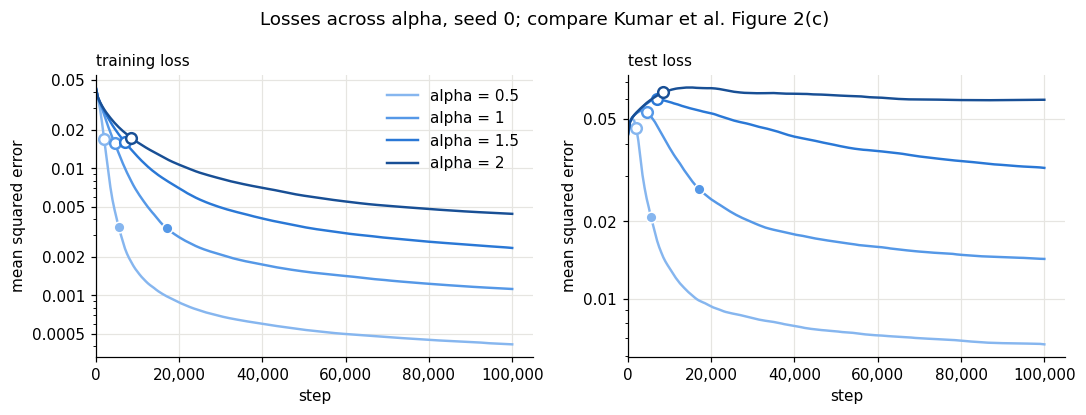

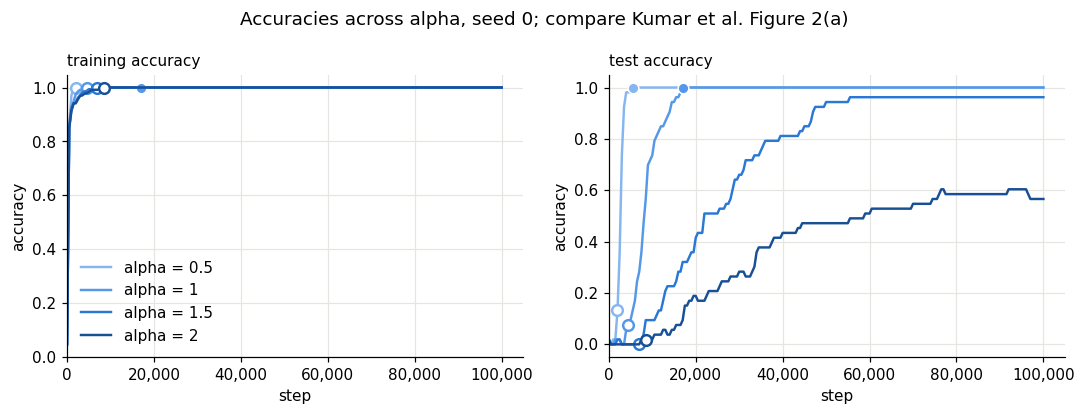

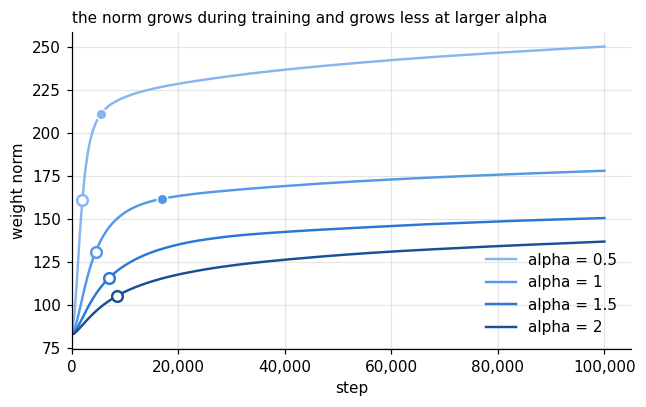

In [4]:
seed0 = [runs[(a, 0)] for a in ALPHAS]
labels = [f"alpha = {a:g}" for a in ALPHAS]
crossings = [L.accuracy_crossings(r, TEST_ACC_LEVEL) for r in seed0]  # the two events of each run, for the dots

# plot_series draws one panel per key with every run overlaid, and marks the events when crossings are given.
fig = L.plot_series(seed0, ["train_loss", "test_loss"], labels, L.RAMP,
                    ["training loss", "test loss"],
                    log_y=("train_loss", "test_loss"), crossings=crossings, log_x=False, mark_train=True,
                    figsize=(10, 3.8), suptitle="Losses across alpha, seed 0; compare Kumar et al. Figure 2(c)")
fig = L.plot_series(seed0, ["train_acc", "test_acc"], labels, L.RAMP,
                    ["training accuracy", "test accuracy"],
                    crossings=crossings, log_x=False, mark_train=True, figsize=(10, 3.8),
                    suptitle="Accuracies across alpha, seed 0; compare Kumar et al. Figure 2(a)")
fig = L.plot_series(seed0, ["weight_norm"], labels, L.RAMP,
                    ["the norm grows during training and grows less at larger alpha"],
                    crossings=crossings, log_x=False, mark_train=True, figsize=(6, 3.8))
fig.axes[0].legend(loc="lower right")


## 4. Grokking time against alpha, all seeds

A circle is a measured grokking time and a triangle a censored lower bound.


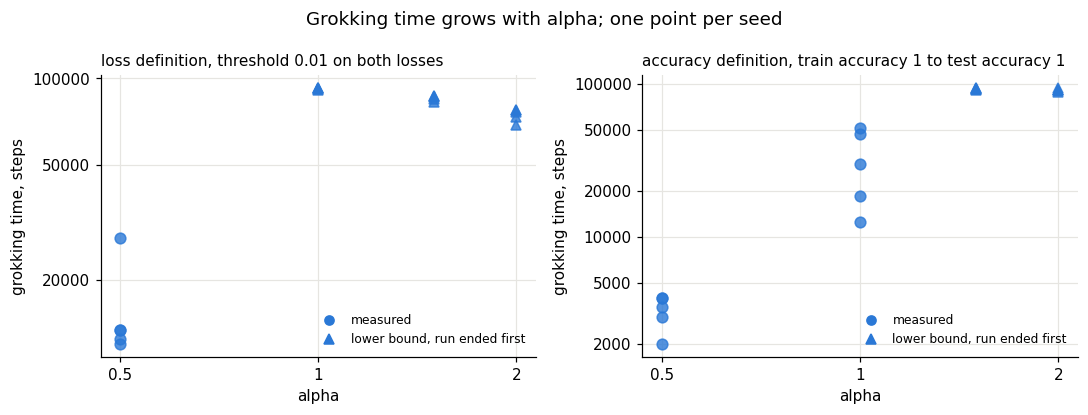

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, definition in zip(axes, ["loss", "accuracy"]):
    for (a, s), run in runs.items():
        row = L.summarise_cell(run, definition, TAU, test_level=TEST_ACC_LEVEL)
        if row["t_grok"] is None:
            continue  # the training event never happened, so there is no grokking time to draw
        ax.plot([a], [row["t_grok"]], "^" if row["censored"] else "o", color=L.BLUE, ms=7, alpha=0.8)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xticks(ALPHAS); ax.set_xticklabels([f"{a:g}" for a in ALPHAS]); ax.minorticks_off()
    ax.set_xlabel("alpha"); ax.set_ylabel("grokking time, steps")
    detail = f", threshold {TAU:g} on both losses" if definition == "loss" else f", train accuracy 1 to test accuracy {TEST_ACC_LEVEL:g}"
    ax.set_title(f"{definition} definition{detail}", loc="left", fontsize=10)
    ax.plot([], [], "o", color=L.BLUE, label="measured")  # legend entries only
    ax.plot([], [], "^", color=L.BLUE, label="lower bound, run ended first")
    ax.legend(fontsize=8, loc="lower right")
    L.tidy_axes(ax)
fig.suptitle("Grokking time grows with alpha; one point per seed")
fig.tight_layout()


## 5. The confound in one cell

The claim that grokking is a transition from lazy to rich training rests on the kernel moving, and the
movement is read off the statistic D = ||K_t - K_0|| / ||K_0||. The identity above says that D is built
from the scale term and the shape term together, so a large D on its own does not say which of the two
moved.

The baseline cell settles the question for itself. The table reports D at three steps, then recomputes it
twice: once with the shape term set to zero, which leaves a kernel that only grew, and once with the
scale term set to zero, which leaves a kernel that only turned. If the first of these is close to D then
almost all of the movement was growth.

In [6]:
def movement(S, R):
    """The relative movement D implied by a scale term and a shape term, Equation 1 of the proposal."""
    return float(np.sqrt(max(np.exp(2 * S) + 1 - 2 * np.exp(S) * (1 - R), 0.0)))

base = runs[(1.0, 0)]
g_base = L.accuracy_crossings(base, TEST_ACC_LEVEL)
marks = [("memorisation", g_base["t_train"]), ("generalisation", g_base["t_test"]),
         ("end of run", int(base["history"]["step"][-1]))]

print(f"{'step':>24} {'D':>8} {'D with R set to 0':>18} {'share':>7} {'D with S set to 0':>18} {'share':>7} "
      f"{'S':>8} {'R':>8} {'A':>8}")
for label, step in marks:
    S, R = L.value_at_step(base, "S_c", step), L.value_at_step(base, "R_c", step)
    A = L.value_at_step(base, "A_t", step)
    D, D_scale, D_shape = movement(S, R), movement(S, 0.0), movement(0.0, R)
    print(f"{label + f' ({step})':>24} {D:>8.3f} {D_scale:>18.3f} {D_scale / D:>6.0%} {D_shape:>18.3f} "
          f"{D_shape / D:>6.0%} {S:>+8.3f} {R:>8.4f} {A:>8.4f}")

print("\nThe kernel of the baseline cell grows by a factor of "
      f"{np.exp(L.value_at_step(base, 'S_c', marks[-1][1])):.1f} over the run "
      f"while its eigenbasis turns by {L.value_at_step(base, 'R_c', marks[-1][1]):.1%}.")

                    step        D  D with R set to 0   share  D with S set to 0   share        S        R        A
     memorisation (4500)    1.709              1.639    96%              0.299    17%   +0.970   0.0447   0.1142
  generalisation (17000)    3.528              3.447    98%              0.355    10%   +1.492   0.0631   0.1163
     end of run (100000)    5.334              5.241    98%              0.397     7%   +1.831   0.0789   0.1065

The kernel of the baseline cell grows by a factor of 6.2 over the run while its eigenbasis turns by 7.9%.


## 6. The confound across the grid

Section 5 uses one cell, so it could be special. This section reads every saved run of the Tier 1 grid at
its own generalisation event and asks how much each quantity varies from cell to cell. A quantity that is
to act as a clock should take about the same value at that event in every cell.

Only runs that generalised appear here, so nothing in this figure can be dismissed as a run that failed to
train.

40 of the saved grid runs generalised.

     quantity at the event      mean       min       max  max/min  spread
                movement D    3.7134    0.5467    7.2358    13.24   56.0%
  kernel norm ratio exp(S)    4.6165    1.3750    8.1539     5.93   45.5%
              shape term R    0.0666    0.0554    0.0829     1.50    7.8%
               alignment A    0.1217    0.1030    0.1381     1.34    6.8%


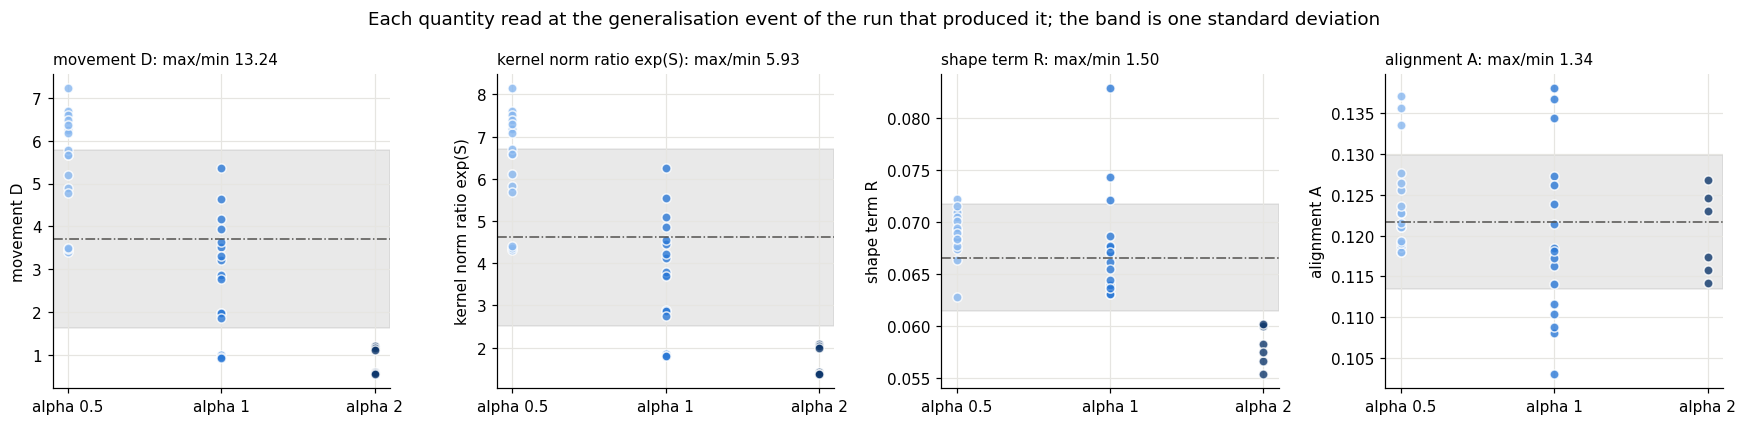

In [7]:
# Every saved grid run that generalised, read at its own generalisation event.
events = []
for a in GRID_ALPHAS:
    for ek in DECAYS:
        for s in SEEDS:
            if not saved(a, s, ek):
                continue
            run = L.load_cell(100, a, ek, s, STEPS, eval_interval=500)
            g = L.accuracy_crossings(run, TEST_ACC_LEVEL)
            if g["censored"]:
                continue
            t = g["t_test"]
            S, R = L.value_at_step(run, "S_c", t), L.value_at_step(run, "R_c", t)
            events.append(dict(alpha=a, ek=ek, seed=s, t_grok=g["t_grok"], S=S, R=R,
                               A=L.value_at_step(run, "A_t", t), A0=run["history"]["A_t"][0],
                               D=movement(S, R)))
print(f"{len(events)} of the saved grid runs generalised.")

panels = [("D", "movement D", lambda e: e["D"]),
          ("expS", "kernel norm ratio exp(S)", lambda e: np.exp(e["S"])),
          ("R", "shape term R", lambda e: e["R"]),
          ("A", "alignment A", lambda e: e["A"])]
alpha_colours = {0.5: L.RAMP[0], 1.0: L.RAMP[2], 2.0: L.RAMP[4]}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.9))
print(f"\n{'quantity at the event':>26} {'mean':>9} {'min':>9} {'max':>9} {'max/min':>8} {'spread':>7}")
for ax, (key, label, get) in zip(axes, panels):
    v = np.array([get(e) for e in events])
    for e, vi in zip(events, v):
        ax.plot([np.log2(e["alpha"])], [vi], "o", color=alpha_colours[e["alpha"]], ms=6, alpha=0.8,
                markeredgecolor="white", lw=0.5)
    ax.axhline(v.mean(), color=L.GRAY, lw=1, ls="-.")
    ax.axhspan(v.mean() - v.std(ddof=1), v.mean() + v.std(ddof=1), color=L.GRAY, alpha=0.12)
    ax.set_xticks([np.log2(a) for a in GRID_ALPHAS])
    ax.set_xticklabels([f"alpha {a:g}" for a in GRID_ALPHAS])
    ax.set_ylabel(label)
    ax.set_title(f"{label}: max/min {v.max() / v.min():.2f}", loc="left", fontsize=10)
    L.tidy_axes(ax)
    print(f"{label:>26} {v.mean():>9.4f} {v.min():>9.4f} {v.max():>9.4f} {v.max() / v.min():>8.2f} "
          f"{v.std(ddof=1) / v.mean():>7.1%}")
fig.suptitle("Each quantity read at the generalisation event of the run that produced it; the band is one standard deviation")
fig.tight_layout()

## 7. Two cells that grok, with the same movement and very different timing

The report asks for two cells with near-equal D and different mechanisms. This section uses two cells that
both memorise and both generalise, so the comparison does not depend on a run that failed.

The pair is alpha 1 with no decay and alpha 0.5 with decay 0.0003. Their movement at the generalisation
event agrees to within a few percent, and their grokking times differ by a factor of several. D therefore
does not carry the timing. The panels show where the two runs differ: in how far the kernel grew, and in
the alignment each had reached when it generalised.

                      cell  memorised  generalised   t_grok  D at event   exp(S)        R        A
         alpha 1, no decay       4500        17000    12500       3.528    4.447   0.0631   0.1163
   alpha 0.5, decay 0.0003       2000         3500     1500       3.394    4.306   0.0689   0.1357


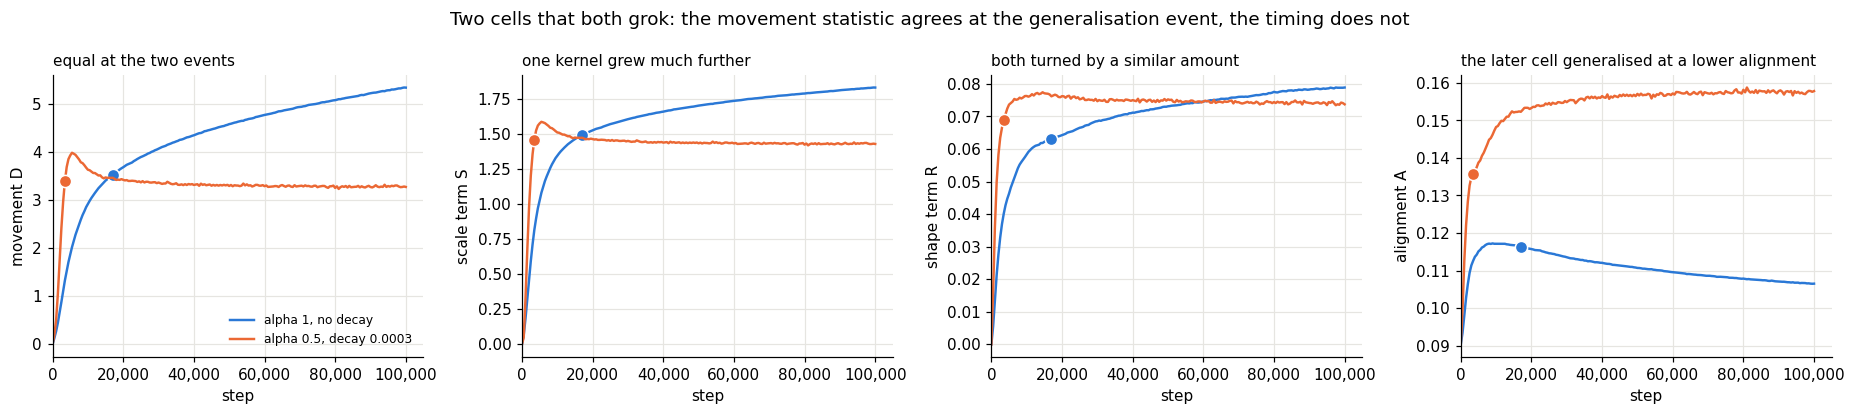

In [8]:
pair = [("alpha 1, no decay", L.load_cell(100, 1.0, 0.0, 0, STEPS, eval_interval=500), L.BLUE),
        ("alpha 0.5, decay 0.0003", L.load_cell(100, 0.5, 3e-4, 0, STEPS, eval_interval=500), L.ORANGE)]

print(f"{'cell':>26} {'memorised':>10} {'generalised':>12} {'t_grok':>8} {'D at event':>11} "
      f"{'exp(S)':>8} {'R':>8} {'A':>8}")
for label, run, _ in pair:
    g = L.accuracy_crossings(run, TEST_ACC_LEVEL)
    t = g["t_test"]
    S, R = L.value_at_step(run, "S_c", t), L.value_at_step(run, "R_c", t)
    print(f"{label:>26} {g['t_train']:>10} {t:>12} {g['t_grok']:>8} {movement(S, R):>11.3f} "
          f"{np.exp(S):>8.3f} {R:>8.4f} {L.value_at_step(run, 'A_t', t):>8.4f}")

keys = [("D", "movement D"), ("S_c", "scale term S"), ("R_c", "shape term R"), ("A_t", "alignment A")]
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
for ax, (key, label) in zip(axes, keys):
    for cell_label, run, colour in pair:
        h = run["history"]
        y = ([movement(S, R) for S, R in zip(h["S_c"], h["R_c"])] if key == "D" else h[key])
        ax.plot(h["step"], y, color=colour, label=cell_label, lw=1.6)
        g = L.accuracy_crossings(run, TEST_ACC_LEVEL)
        t = g["t_test"]
        yt = movement(L.value_at_step(run, "S_c", t), L.value_at_step(run, "R_c", t)) if key == "D" \
            else L.value_at_step(run, key, t)
        ax.plot([t], [yt], "o", color=colour, ms=8, markeredgecolor="white")
    ax.set_xlabel("step"); ax.set_ylabel(label)
    L.linear_step_axis(ax)
    L.tidy_axes(ax)
axes[0].set_title("equal at the two events", loc="left", fontsize=10)
axes[1].set_title("one kernel grew much further", loc="left", fontsize=10)
axes[2].set_title("both turned by a similar amount", loc="left", fontsize=10)
axes[3].set_title("the later cell generalised at a lower alignment", loc="left", fontsize=10)
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle("Two cells that both grok: the movement statistic agrees at the generalisation event, the timing does not")
fig.tight_layout()

## 8. The collapse cell, shown over the whole run

The cell at weight decay 0.001 is the clearest case of a kernel that shrinks, and the Tier 1 notebook used
it to make the H0 point. It is kept here for that reason, with three things said plainly that the earlier
figure did not say.

It sits outside the pre-registered decay axis, which stops at 0.0003. It never memorises, so it is not a
run that groks late but a run that does not fit the training set. And its alignment is not flat. It is
flat only for the first few thousand steps, and over the run it rises above the alignment the baseline cell
ever reaches, while never generalising.

That last fact is a result in its own right and belongs in the report. A run can reach the alignment band
that the grokking cells occupy at their generalisation event and still not generalise, so crossing that
band is not sufficient for generalisation.

              step        D        S        R        A  train acc  test acc
      grow    2000    0.659   +0.463   0.0276   0.1064      0.975     0.019
    shrink    2500    0.606   -0.841   0.0511   0.0908      0.149     0.000

Over the whole run the growing cell reaches a peak alignment of 0.1172 and the shrinking cell 0.1315.
The growing cell generalises at step 17000; the shrinking cell reaches a training accuracy of only 0.943 and never generalises.


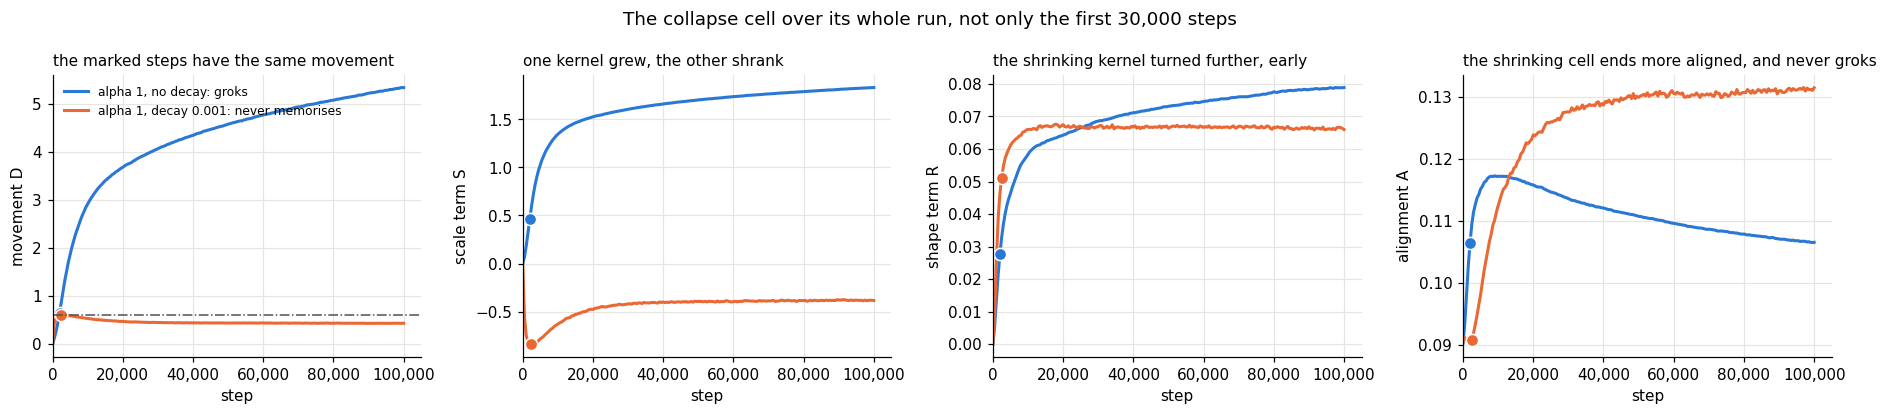

In [9]:
grow = runs[(1.0, 0)]                                              # baseline, the kernel grows
shrink = L.load_cell(100, 1.0, 1e-3, 0, STEPS, eval_interval=500)  # decay 0.001, the kernel collapses

def path(run):
    h = run["history"]
    D = np.array([movement(S, R) for S, R in zip(h["S_c"], h["R_c"])])
    return (np.asarray(h["step"]), D, np.asarray(h["S_c"]), np.asarray(h["R_c"]), np.asarray(h["A_t"]))

sg, Dg, Sg, Rg, Ag = path(grow)
ss, Ds, Ss, Rs, As = path(shrink)
j = int(np.argmin(Ss))          # the shrinking cell at the bottom of its collapse
i = int(np.argmax(Dg >= Ds[j])) # the first step at which the growing cell has reached the same movement

print(f"{'':>10} {'step':>7} {'D':>8} {'S':>8} {'R':>8} {'A':>8} {'train acc':>10} {'test acc':>9}")
for label, run, k in [("grow", grow, i), ("shrink", shrink, j)]:
    h = run["history"]
    print(f"{label:>10} {h['step'][k]:>7} {movement(h['S_c'][k], h['R_c'][k]):>8.3f} {h['S_c'][k]:>+8.3f} "
          f"{h['R_c'][k]:>8.4f} {h['A_t'][k]:>8.4f} {h['train_acc'][k]:>10.3f} {h['test_acc'][k]:>9.3f}")
print(f"\nOver the whole run the growing cell reaches a peak alignment of {Ag.max():.4f} and the "
      f"shrinking cell {As.max():.4f}.")
print(f"The growing cell generalises at step {L.accuracy_crossings(grow, TEST_ACC_LEVEL)['t_test']}; "
      f"the shrinking cell reaches a training accuracy of only {max(shrink['history']['train_acc']):.3f} "
      "and never generalises.")

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
for ax, (yg, ys), label in zip(axes, [(Dg, Ds), (Sg, Ss), (Rg, Rs), (Ag, As)],
                               ["movement D", "scale term S", "shape term R", "alignment A"]):
    ax.plot(sg, yg, color=L.BLUE, label="alpha 1, no decay: groks")
    ax.plot(ss, ys, color=L.ORANGE, label="alpha 1, decay 0.001: never memorises")
    ax.plot([sg[i]], [yg[i]], "o", color=L.BLUE, ms=8, markeredgecolor="white")
    ax.plot([ss[j]], [ys[j]], "o", color=L.ORANGE, ms=8, markeredgecolor="white")
    ax.set_xlabel("step"); ax.set_ylabel(label)
    L.linear_step_axis(ax)
    L.tidy_axes(ax)
axes[0].axhline(Ds[j], color=L.GRAY, lw=1, ls="-.")
axes[0].set_title("the marked steps have the same movement", loc="left", fontsize=10)
axes[1].set_title("one kernel grew, the other shrank", loc="left", fontsize=10)
axes[2].set_title("the shrinking kernel turned further, early", loc="left", fontsize=10)
axes[3].set_title("the shrinking cell ends more aligned, and never groks", loc="left", fontsize=10)
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("The collapse cell over its whole run, not only the first 30,000 steps")
fig.tight_layout()